In [39]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import report_ensemble
from diabnet.ensemble import Ensemble
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ensemble = Ensemble('../diabnet/models/model-4-soft-label-age-positives-500-dropout0-bn-decay-flood-hyperopt-ax-batch256-adamw-lc2-20201001')
r = report_ensemble.DiabNetReport(ensemble, "positivo_1000_random_0.csv")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
../diabnet/models/model-4-soft-label-age-positives-500-dropout0-bn-decay-flood-hyperopt-ax-batch256-adamw-lc2-20201001
NEGATIVE FILE ../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv


In [40]:
df = pd.DataFrame(r.dataset_test_unique.features)
df.columns = r.feat_names
df['T2D'] = r.dataset_test_unique.labels
df['Pred'] = r.dataset_test_unique.predictions

## Por que alguns pacientes diabéticos não são identificados?

Quais caracerísticas diferem "true positives" de "false negatives"?

**Hipótese:** Os "false negatives" tem maior contribuição ambiental e menor contribuição genética.

*Possíveis pistas:*
- Frequência no diagnóstico dos pais.
- Idade
- BMI
- ~Sexo~

In [41]:
df0 = df[df.T2D == 1]
df0 = df0[['AGE','sex','mo_t2d', 'fa_t2d', 'Pred']]
# df0['positives'] = df0.Pred < .5 
df0['positives'] = ["wrong" if x else "right" for x in df0.Pred < .5]  

In [42]:
df0[df0.positives == 'right']

,AGE,sex,mo_t2d,fa_t2d,Pred,positives
0,51,M,2,2,0.874763,right
5,53,F,1,1,0.988029,right
6,39,F,2,0,0.999394,right
13,40,F,2,1,0.591664,right
15,28,F,0,2,0.993653,right
...,...,...,...,...,...,...
539,53,F,1,1,0.536329,right
540,52,M,2,2,0.973118,right
541,38,F,1,1,0.779627,right
542,54,F,2,2,0.988189,right


In [43]:
df0

,AGE,sex,mo_t2d,fa_t2d,Pred,positives
0,51,M,2,2,0.874763,right
2,52,F,0,2,0.424887,wrong
5,53,F,1,1,0.988029,right
6,39,F,2,0,0.999394,right
13,40,F,2,1,0.591664,right
...,...,...,...,...,...,...
539,53,F,1,1,0.536329,right
540,52,M,2,2,0.973118,right
541,38,F,1,1,0.779627,right
542,54,F,2,2,0.988189,right


<AxesSubplot:xlabel='positives', ylabel='AGE'>

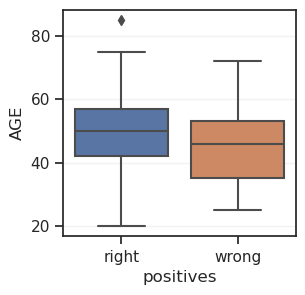

In [44]:
plt.figure(figsize=(3,3), dpi=100)
sns.boxplot(y='AGE', x='positives', data=df0)

<AxesSubplot:xlabel='sex', ylabel='count'>

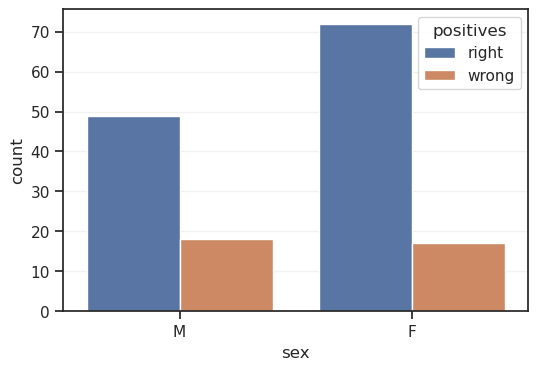

In [45]:
plt.figure( dpi=100)
sns.countplot(x='sex', hue='positives', data=df0)

<AxesSubplot:xlabel='mo_t2d', ylabel='count'>

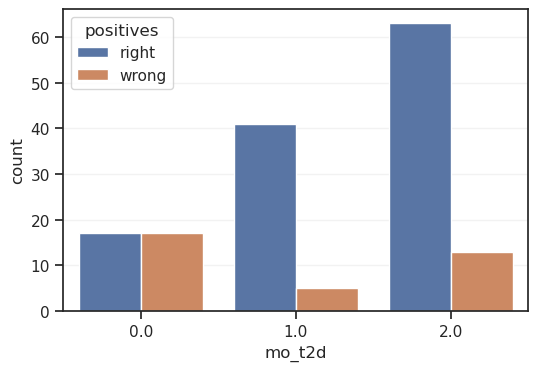

In [46]:
plt.figure( dpi=100)
sns.countplot(x='mo_t2d', hue='positives', data=df0)

<AxesSubplot:xlabel='fa_t2d', ylabel='count'>

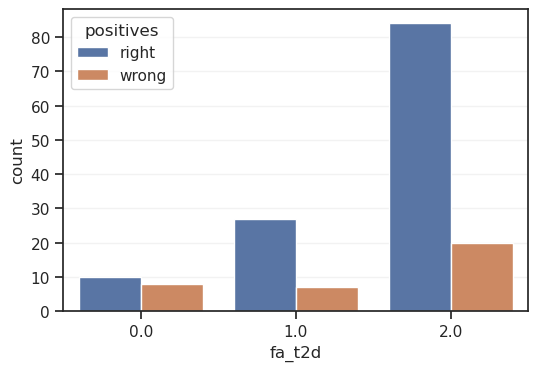

In [47]:
plt.figure( dpi=100)
sns.countplot(x='fa_t2d', hue='positives', data=df0)

<AxesSubplot:xlabel='mo_t2d', ylabel='AGE'>

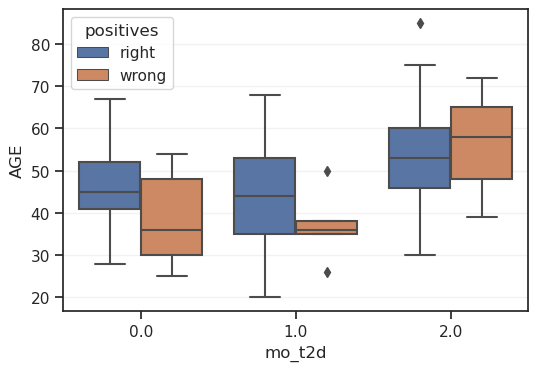

In [48]:
plt.figure( dpi=100)
sns.boxplot(y='AGE', x='mo_t2d',hue='positives', data=df0)

In [49]:
pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_negative_0.csv")

,Unnamed: 0,id,snp_8_133462953,snp_2_91635413,snp_9_25963828,snp_1_17764169,snp_12_41767967,snp_4_49530811,snp_2_96519717,snp_7_116910447,...,snp_1_143276644,snp_16_9536673,snp_20_25734788,AGE,T2D,sex,mo,fa,mo_t2d,fa_t2d
0,0,A11123,0,0,0,0,0,0,0,0,...,0,0,0,51,1,M,0,0,2.0,2.0
1,1,A00551,0,0,0,1,0,1,1,0,...,1,0,1,40,0,F,A00548,A00547,0.0,1.0
2,2,A02267,0,0,0,0,0,1,0,0,...,1,0,0,52,1,F,A02254,A20031,0.0,2.0
3,3,A00586,0,0,0,0,0,1,0,0,...,1,0,0,34,0,M,A00300,A00585,0.0,1.0
4,4,A16039,0,0,0,0,0,1,0,0,...,0,0,0,37,0,F,A02064,A02063,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,545,A02889,0,2,0,1,0,1,1,0,...,1,0,1,36,0,M,A02156,A02149,1.0,0.0
546,546,A26102,0,0,0,0,0,0,0,0,...,0,0,0,41,0,M,A01009,A26053,0.0,2.0
547,547,A03220,0,0,1,0,0,0,0,0,...,0,0,0,67,0,F,A23019,A23015,2.0,2.0
548,548,A39026,0,0,1,1,0,1,1,0,...,1,0,1,41,0,F,A39014,A39020,0.0,2.0


## Qual o perfil dos não diabéticos preditos como diabéticos?

........

In [50]:
df1 = df[df.T2D == 0]
df1 = df1[['AGE','sex','mo_t2d', 'fa_t2d', 'Pred']]
# df0['positives'] = df0.Pred < .5 
df1['negatives'] = ["right" if x else "wrong" for x in df1.Pred < .5] 

In [51]:
df1[df1.negatives == 'wrong']

,AGE,sex,mo_t2d,fa_t2d,Pred,negatives
7,61,F,2,2,0.578559,wrong
8,52,F,0,2,0.594510,wrong
40,63,F,2,2,0.633674,wrong
53,64,F,0,2,0.697051,wrong
66,60,F,2,2,0.662566,wrong
68,62,F,2,2,0.804899,wrong
71,58,F,0,0,0.524792,wrong
86,64,F,2,1,0.553998,wrong
91,35,M,0,2,0.628831,wrong
98,47,F,1,2,0.764681,wrong


<AxesSubplot:xlabel='negatives', ylabel='AGE'>

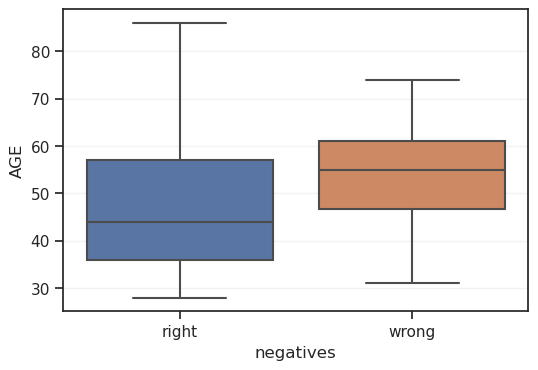

In [52]:
plt.figure( dpi=100)
sns.boxplot(y='AGE', x='negatives', data=df1)

<AxesSubplot:xlabel='sex', ylabel='count'>

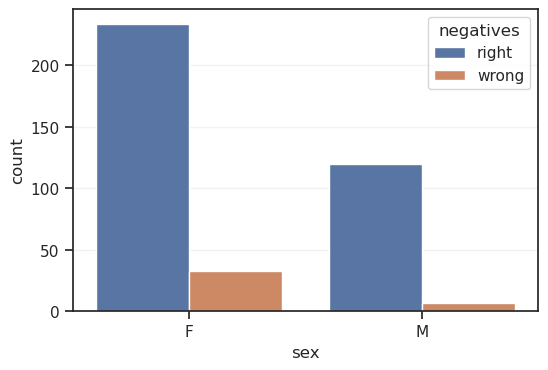

In [53]:
plt.figure( dpi=100)
sns.countplot(x='sex', hue='negatives', data=df1)

<AxesSubplot:xlabel='mo_t2d', ylabel='count'>

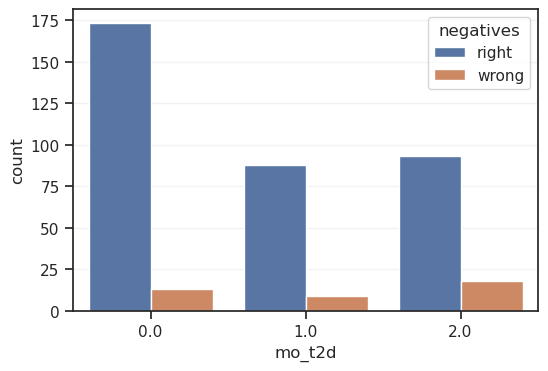

In [54]:
plt.figure( dpi=100)
sns.countplot(x='mo_t2d', hue='negatives', data=df1)

<AxesSubplot:xlabel='fa_t2d', ylabel='count'>

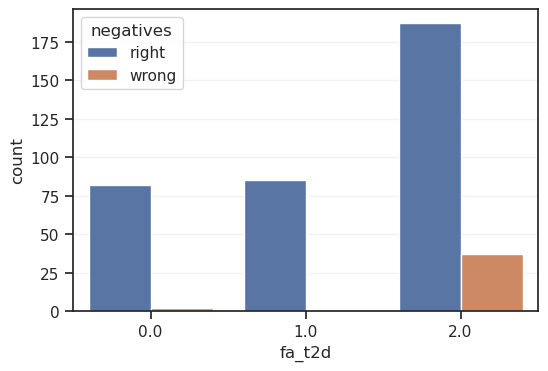

In [55]:
plt.figure( dpi=100)
sns.countplot(x='fa_t2d', hue='negatives', data=df1)